# Import Libraries

In [139]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Part 1: Dataset Loading and Exploration

Step 1. Load Dataset

In [140]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

Step 2. Display First Five Records

In [141]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


Step 3. Display Last Five Records

In [142]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


Step 4. Check Dataset Dimensions

In [143]:
df.shape

(5110, 12)

Step 5. Display Column Names

In [144]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

Step 6. Display Data Types

In [145]:
df.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

Step 7. Summary Statistics

In [146]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


Step 8. Identify Numerical Features

In [147]:
numerical = df.select_dtypes(include=['int64','float64'])

print(numerical.columns)

Index(['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level',
       'bmi', 'stroke'],
      dtype='object')


Step 9. Identify Categorical Features

In [148]:
categorical = df.select_dtypes(include=['object'])

print(categorical.columns)

Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object')


Step 10. Identify Target Variable

In [149]:
target = 'stroke'

print(df[target].value_counts())

stroke
0    4861
1     249
Name: count, dtype: int64


# Part 2: Data Quality Assessment

Step 11. Check Missing Values

In [150]:
target = 'stroke'

print(df[target].value_counts())

stroke
0    4861
1     249
Name: count, dtype: int64


Step 12. Check Duplicate Records

In [151]:
df.duplicated().sum()

np.int64(0)

If duplicates exist;

In [152]:
df[df.duplicated()]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke


Step 13. Check Incorrect Data Types

In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


Step 14. Check Inconsistent Categories

In [154]:
for col in categorical.columns:
    print(col)
    print(df[col].unique())
    print()

gender
['Male' 'Female' 'Other']

ever_married
['Yes' 'No']

work_type
['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']

Residence_type
['Urban' 'Rural']

smoking_status
['formerly smoked' 'never smoked' 'smokes' 'Unknown']



Step 15. Detect Outliers using IQR

In [155]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['bmi'] < lower) | (df['bmi'] > upper)]

print(outliers.shape)

(110, 12)


Step 16. Draw Boxplot

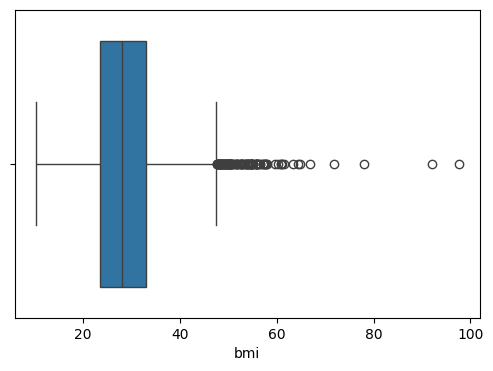

In [156]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df['bmi'])

plt.show()

# Part 3: Data Preprocessing

In [157]:
df_row_deleted = df.dropna()

In [158]:
df['bmi'].fillna(df['bmi'].mean(), inplace=True)

/var/folders/_w/j1vksszx0h5bqm6j_y5xyz2c0000gn/T/ipykernel_1451/3594416367.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].mean(), inplace=True)


In [159]:
df['bmi'].fillna(df['bmi'].median(), inplace=True)

/var/folders/_w/j1vksszx0h5bqm6j_y5xyz2c0000gn/T/ipykernel_1451/1439978410.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(), inplace=True)


In [160]:
df['smoking_status'].fillna(df['smoking_status'].mode()[0], inplace=True)

/var/folders/_w/j1vksszx0h5bqm6j_y5xyz2c0000gn/T/ipykernel_1451/946677556.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['smoking_status'].fillna(df['smoking_status'].mode()[0], inplace=True)


In [161]:
df.drop_duplicates(inplace=True)

In [162]:
df['stroke'] = df['stroke'].astype(int)

In [163]:
df['gender'] = df['gender'].str.strip()

df['gender'] = df['gender'].str.title()

In [164]:
df = df[(df['bmi']>=lower) & (df['bmi']<=upper)]

In [165]:
df['bmi'] = np.where(df['bmi']>upper, upper, df['bmi'])

df['bmi'] = np.where(df['bmi']<lower, lower, df['bmi'])

Saving the Cleaned Dataset (.csv)

In [166]:
df.to_csv("cleaned_stroke_data.csv", index=False)

# Part 4: Feature Engineering


In [167]:
df['BMI_Category'] = pd.cut(
    df['bmi'],
    bins=[0,18.5,25,30,100],
    labels=['Underweight','Normal','Overweight','Obese']
)

In [168]:
df['Age_Group'] = pd.cut(
    df['age'],
    bins=[0,18,40,60,100],
    labels=['Child','Young Adult','Middle Age','Senior']
)

In [169]:
df['Hypertension_Risk'] = (
    df['hypertension'] +
    df['heart_disease']
)

In [170]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke', 'BMI_Category', 'Age_Group',
       'Hypertension_Risk'],
      dtype='object')

In [171]:
df.to_csv("feature_engineered_stroke_data.csv", index=False)

# Part 5: Feature Handling

In [172]:
X = df.drop(['id', 'stroke'], axis=1)
y = df['stroke']

In [173]:
num = X.select_dtypes(include=['int64', 'float64'])

In [174]:
cat = X.select_dtypes(include=['object','category'])

In [175]:
le = LabelEncoder()

df['ever_married'] = le.fit_transform(df['ever_married'])

In [176]:
df = pd.get_dummies(
    df,
    columns=['gender','work_type','Residence_type','smoking_status'],
    drop_first=True
)

In [177]:
scaler = StandardScaler()

scaled_standard = scaler.fit_transform(num)

In [178]:
minmax = MinMaxScaler()

scaled_minmax = minmax.fit_transform(num)

In [179]:
X = df.drop(['id', 'stroke'], axis=1)

y = df['stroke']

In [180]:
standard_df = pd.DataFrame(
    scaled_standard,
    columns=num.columns
)

minmax_df = pd.DataFrame(
    scaled_minmax,
    columns=num.columns
)

print("StandardScaler")
print(standard_df.head())

print("\nMinMaxScaler")
print(minmax_df.head())

StandardScaler
        age  hypertension  heart_disease  avg_glucose_level       bmi  \
0  1.045093     -0.324748       4.145096           2.733462  1.232822   
1  0.781631     -0.324748      -0.241249           2.144254  0.083005   
2  1.615928     -0.324748       4.145096           0.001701  0.621119   
3  0.254706     -0.324748      -0.241249           1.454917  0.904591   
4  1.572018      3.079315      -0.241249           1.519223 -0.647046   

   Hypertension_Risk  
0           2.169354  
1          -0.384029  
2           2.169354  
3          -0.384029  
4           2.169354  

MinMaxScaler
        age  hypertension  heart_disease  avg_glucose_level       bmi  \
0  0.816895           0.0            1.0           0.801265  0.706989   
1  0.743652           0.0            0.0           0.679023  0.499818   
2  0.975586           0.0            1.0           0.234512  0.596774   
3  0.597168           0.0            0.0           0.536008  0.647849   
4  0.963379           1.0    

In [181]:
print(num.columns)

Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',
       'Hypertension_Risk'],
      dtype='object')
